2015: 338 train weeks, 50 val weeks; best {'hidden': 32, 'dropout': 0.2, 'lam': 0.0}; val weekly net Sharpe (ann.) 0.562
2016: 390 train weeks, 50 val weeks; best {'hidden': 64, 'dropout': 0.2, 'lam': 0.0}; val weekly net Sharpe (ann.) 1.630
2017: 442 train weeks, 51 val weeks; best {'hidden': 64, 'dropout': 0.2, 'lam': 0.0}; val weekly net Sharpe (ann.) -0.110
2018: 495 train weeks, 50 val weeks; best {'hidden': 64, 'dropout': 0.2, 'lam': 0.0}; val weekly net Sharpe (ann.) 0.728
2019: 547 train weeks, 50 val weeks; best {'hidden': 64, 'dropout': 0.2, 'lam': 0.0}; val weekly net Sharpe (ann.) 2.323
2020: 599 train weeks, 50 val weeks; best {'hidden': 64, 'dropout': 0.2, 'lam': 0.0}; val weekly net Sharpe (ann.) -1.385
2021: 651 train weeks, 50 val weeks; best {'hidden': 64, 'dropout': 0.2, 'lam': 0.0}; val weekly net Sharpe (ann.) 3.142
2022: 703 train weeks, 51 val weeks; best {'hidden': 64, 'dropout': 0.2, 'lam': 0.0}; val weekly net Sharpe (ann.) 0.498
2023: 756 train weeks, 50 val 

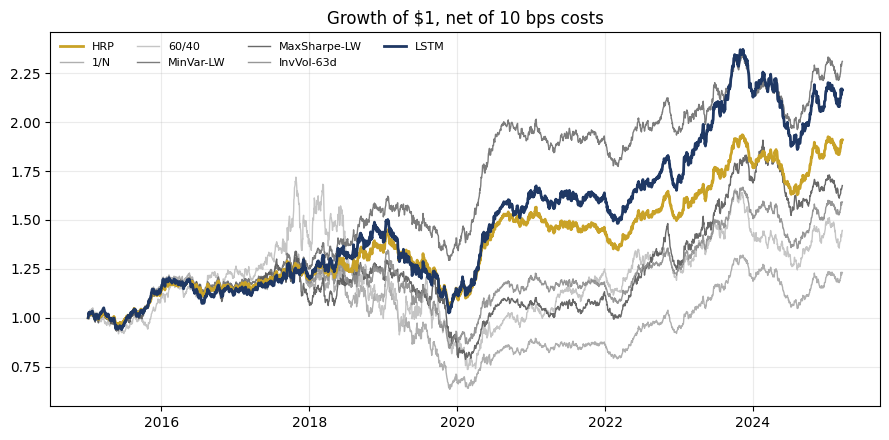

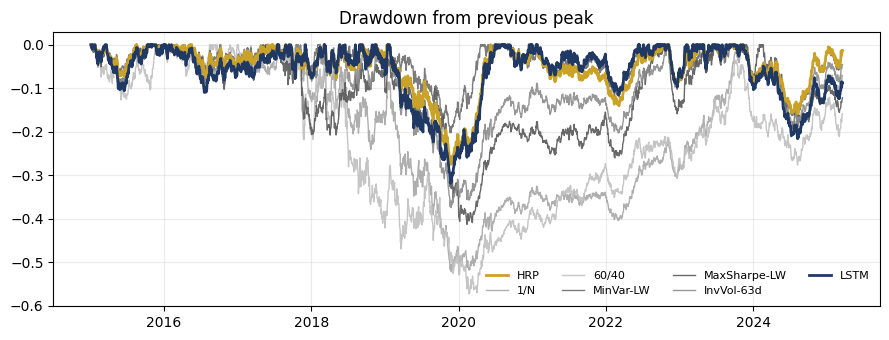

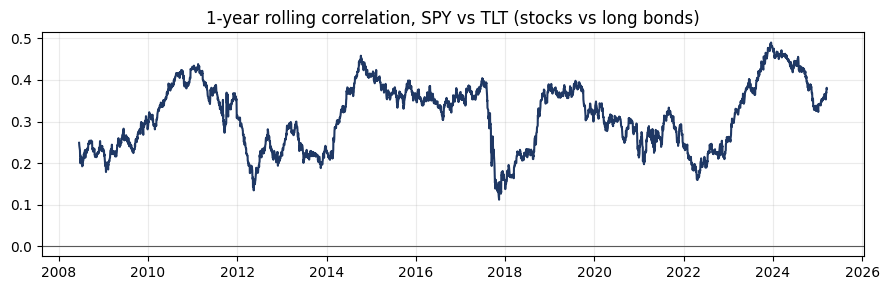

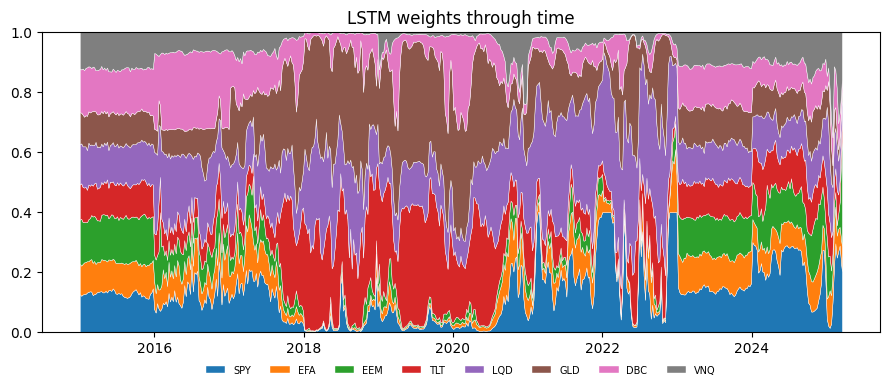

               CAGR    Vol  Sharpe  MaxDD  Calmar  CVaR95(daily)  Turnover/yr
HRP           0.063  0.107   0.627 -0.275   0.230         -0.014        1.673
1/N           0.020  0.152   0.206 -0.522   0.038         -0.022        1.158
60/40         0.036  0.195   0.277 -0.573   0.062         -0.029        0.809
MinVar-LW     0.083  0.099   0.851 -0.202   0.408         -0.013        1.837
MaxSharpe-LW  0.050  0.137   0.424 -0.413   0.121         -0.019        8.294
InvVol-63d    0.045  0.126   0.413 -0.374   0.120         -0.017        1.717
LSTM          0.076  0.120   0.670 -0.318   0.238         -0.016        6.901

Saved to outputs/synthetic_main
weights_1-N.csv              sum=1: True   cap<=40%: True   max=0.125
weights_60-40.csv            sum=1: True   cap<=40%: True   max=0.600
weights_HRP.csv              sum=1: True   cap<=40%: True   max=0.400
weights_InvVol-63d.csv       sum=1: True   cap<=40%: True   max=0.275
weights_LSTM.csv             sum=1: True   cap<=40%: True   max

True

In [2]:
# %pip install -q yfinance torch scikit-learn scipy   # uncomment if needed in Colab

"""
Single-file study: config, data, features, benchmarks, LSTM allocator,
backtest, run pipeline and mechanical checks.
"""
import argparse
import glob
import io
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.optimize import minimize
from scipy.spatial.distance import squareform
from scipy.stats import norm
from sklearn.covariance import LedoitWolf

# =====================================================================
# CONFIG
# =====================================================================
TICKERS = ["SPY", "EFA", "EEM", "TLT", "LQD", "GLD", "DBC", "VNQ"]
START, END = "2007-01-01", "2025-12-31"
MACRO = {"VIXCLS": "vix", "T10Y2Y": "curve", "DTWEXBGS": "usd"}

W_MAX = 0.40
COST_BPS = 10
COST_GRID_BPS = [0, 10, 25, 50]
REBAL_FREQ = "W-FRI"
PERIODS_PER_YEAR = 52
COV_WINDOW = 252
INVVOL_WINDOW = 63

FIRST_TEST_YEAR, LAST_TEST_YEAR = 2015, 2025
PURGE_DAYS = 5

LOOKBACK = 60
HORIZON = 5
GRID = [
    {"hidden": 32, "dropout": 0.2, "lam": 0.0},
    {"hidden": 64, "dropout": 0.2, "lam": 0.0},
    {"hidden": 32, "dropout": 0.2, "lam": 0.5},
    {"hidden": 64, "dropout": 0.2, "lam": 0.5},
]
SEEDS = 10
MAX_EPOCHS = 100
PATIENCE = 10
BATCH_WEEKS = 26
LR = 1e-3

STRESS_WINDOWS = {
    "Q4-2018 sell-off":       ("2018-10-01", "2018-12-24"),
    "COVID crash 2020":       ("2020-02-19", "2020-03-23"),
    "2022 stocks+bonds fall": ("2022-01-03", "2022-10-12"),
}
SUB_PERIODS = {
    "2015-2019 (pre-COVID)":         ("2015-01-01", "2019-12-31"),
    "2020 (COVID crash & recovery)": ("2020-01-01", "2020-12-31"),
    "2021 (post-COVID recovery)":    ("2021-01-01", "2021-12-31"),
    "2022 (stock-bond sell-off)":    ("2022-01-01", "2022-12-31"),
    "2023-2025 (post-tightening)":   ("2023-01-01", "2025-12-31"),
}

DATA_DIR = "data"
OUT_DIR = "outputs"

NAVY, GOLD = "#1F3864", "#C9A227"
GREYS = ["#8C8C8C", "#A6A6A6", "#BFBFBF", "#6E6E6E", "#595959"]


# =====================================================================
# DATA
# =====================================================================
def _cache(name):
    os.makedirs(DATA_DIR, exist_ok=True)
    return os.path.join(DATA_DIR, name)


def load_prices(tickers=TICKERS, start=START, end=END, refresh=False):
    path = _cache("prices.csv")
    if os.path.exists(path) and not refresh:
        return pd.read_csv(path, index_col=0, parse_dates=True)[tickers]
    import yfinance as yf
    px = yf.download(tickers, start=start, end=end, auto_adjust=True,
                     progress=False)["Close"][tickers]
    px = px.dropna(how="all").ffill().dropna()
    px.to_csv(path)
    return px


def load_macro(start=START, end=END, refresh=False):
    path = _cache("macro.csv")
    if os.path.exists(path) and not refresh:
        return pd.read_csv(path, index_col=0, parse_dates=True)
    frames = []
    for code, name in MACRO.items():
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={code}"
        raw = urllib.request.urlopen(url, timeout=30).read().decode()
        s = pd.read_csv(io.StringIO(raw), index_col=0, parse_dates=True,
                        na_values=".").iloc[:, 0].rename(name)
        frames.append(s)
    m = pd.concat(frames, axis=1).loc[start:end]
    m.to_csv(path)
    return m


def align(prices, macro):
    """Put macro on the trading calendar, forward-fill gaps, lag one day."""
    macro = macro.reindex(prices.index).ffill().shift(1)
    ok = macro.notna().all(axis=1)
    return prices[ok], macro[ok]


def synthetic(n_days=4750, seed=0):
    """Fake data with calm and stressed regimes. ONLY for testing that the code runs."""
    rng = np.random.default_rng(seed)
    idx = pd.bdate_range("2007-01-03", periods=n_days)
    k = len(TICKERS)
    regime = (np.sin(np.arange(n_days) / 400) > 0.6).astype(int)
    mu = np.array([[4, 4, 5, 2, 2, 2, 1, 4], [-20, -22, -28, 8, -4, 6, -15, -25]]) / 1e4
    vol = np.array([[1.0, 1.1, 1.4, 0.8, 0.5, 0.9, 1.1, 1.3],
                    [3.0, 3.2, 3.8, 1.2, 1.0, 1.5, 2.5, 3.5]]) / 100
    base_corr = 0.3 + 0.7 * np.eye(k)
    L = np.linalg.cholesky(base_corr)
    z = rng.standard_normal((n_days, k)) @ L.T
    r = mu[regime] + vol[regime] * z
    prices = pd.DataFrame(100 * np.exp(np.cumsum(r, axis=0)), idx, TICKERS)
    macro = pd.DataFrame({
        "vix": 15 + 20 * regime + rng.normal(0, 2, n_days),
        "curve": 1 + np.cumsum(rng.normal(0, 0.02, n_days)),
        "usd": 100 * np.exp(np.cumsum(rng.normal(0, 0.003, n_days))),
    }, idx)
    return prices, macro


# =====================================================================
# FEATURES
# =====================================================================
def build_features(prices, macro, use_macro=True):
    lr = np.log(prices).diff()
    blocks = {
        "r1": lr,
        "r5": lr.rolling(5).sum(),
        "r21": lr.rolling(21).sum(),
        "v21": lr.rolling(21).std() * np.sqrt(252),
        "v63": lr.rolling(63).std() * np.sqrt(252),
        "m126": lr.rolling(126).sum(),
    }
    parts = [b.add_prefix(f"{k}_") for k, b in blocks.items()]
    if use_macro:
        m = pd.DataFrame({
            "vix": macro["vix"],
            "curve": macro["curve"],
            "usd21": np.log(macro["usd"]).diff(21),
        })
        parts.append(m)
    return pd.concat(parts, axis=1).dropna()


# =====================================================================
# BENCHMARKS
# =====================================================================
def cap_weights(w, cap=W_MAX, iters=20):
    """Clip any weight above the cap and hand the excess to the others pro-rata."""
    w = w.copy()
    for _ in range(iters):
        over = w > cap
        if not over.any():
            break
        excess = (w[over] - cap).sum()
        w[over] = cap
        under = ~over
        w[under] += excess * w[under] / w[under].sum()
    return w


def equal_weight(rets):
    return pd.Series(1.0 / rets.shape[1], rets.columns)


def sixty_forty(rets):
    w = pd.Series(0.0, rets.columns)
    w["SPY"], w["TLT"] = 0.6, 0.4
    return w


def inverse_vol(rets, window=INVVOL_WINDOW):
    vol = rets.iloc[-window:].std()
    w = 1 / vol
    return cap_weights(w / w.sum())


def _cluster_var(cov, items):
    c = cov.loc[items, items].values
    ivp = 1 / np.diag(c)
    ivp /= ivp.sum()
    return float(ivp @ c @ ivp)


def hrp(rets):
    """Lopez de Prado (2016): cluster by correlation, then split risk top-down."""
    cov, corr = rets.cov(), rets.corr()
    dist = np.sqrt(np.clip((1 - corr) / 2, 0, None))
    link = linkage(squareform(dist.values, checks=False), method="single")
    order = list(rets.columns[leaves_list(link)])

    w = pd.Series(1.0, order)
    clusters = [order]
    while clusters:
        clusters = [c[j:k] for c in clusters
                    for j, k in ((0, len(c) // 2), (len(c) // 2, len(c))) if len(c) > 1]
        for i in range(0, len(clusters), 2):
            left, right = clusters[i], clusters[i + 1]
            vl, vr = _cluster_var(cov, left), _cluster_var(cov, right)
            alpha = 1 - vl / (vl + vr)
            w[left] *= alpha
            w[right] *= 1 - alpha
    return cap_weights(w[rets.columns])


def _lw_cov(rets):
    return LedoitWolf().fit(rets.values).covariance_ * 252


def _solve(obj, n):
    cons = ({"type": "eq", "fun": lambda w: w.sum() - 1},)
    res = minimize(obj, np.full(n, 1 / n), bounds=[(0, W_MAX)] * n,
                   constraints=cons, method="SLSQP")
    w = np.clip(res.x, 0, None)
    return w / w.sum()


def min_variance(rets):
    S = _lw_cov(rets)
    return pd.Series(_solve(lambda w: w @ S @ w, S.shape[0]), rets.columns)


def max_sharpe(rets):
    S = _lw_cov(rets)
    mu = rets.mean().values * 252
    obj = lambda w: -(w @ mu) / np.sqrt(w @ S @ w + 1e-12)
    return pd.Series(_solve(obj, S.shape[0]), rets.columns)


RULES = {
    "HRP": (hrp, COV_WINDOW),
    "1/N": (equal_weight, 1),
    "60/40": (sixty_forty, 1),
    "MinVar-LW": (min_variance, COV_WINDOW),
    "MaxSharpe-LW": (max_sharpe, COV_WINDOW),
    "InvVol-63d": (inverse_vol, INVVOL_WINDOW),
}


def benchmark_weights(daily_rets, decision_dates_):
    """Weights for every rule on every decision date, using data up to that date only."""
    out = {name: {} for name in RULES}
    for d in decision_dates_:
        hist = daily_rets.loc[:d]
        for name, (fn, need) in RULES.items():
            if name == "60/40" and not {"SPY", "TLT"} <= set(daily_rets.columns):
                continue
            if len(hist) >= need:
                out[name][d] = fn(hist.iloc[-max(need, 2):])
    return {k: pd.DataFrame(v).T for k, v in out.items() if v}


# =====================================================================
# BACKTEST
# =====================================================================
def decision_dates(index, start=None, end=None):
    s = pd.Series(index, index=index).loc[start:end]
    return list(s.groupby(s.index.to_period("W-FRI")).last().values)


def simulate(prices, target_w):
    """Daily gross return and turnover. Decisions trade at next trading day's close."""
    rets = prices.pct_change().fillna(0.0)
    idx = prices.index
    exec_map = {}
    for d, w in target_w.iterrows():
        pos = idx.searchsorted(d, side="right")
        if pos < len(idx):
            exec_map[idx[pos]] = w.reindex(prices.columns).fillna(0).values
    start = min(exec_map)
    days = idx[idx >= start]
    w = np.zeros(prices.shape[1])
    gross, turn = [], []
    for day in days:
        r = rets.loc[day].values
        port_r = float(w @ r)
        w = w * (1 + r)
        w = w / w.sum() if w.sum() > 0 else w
        t = 0.0
        if day in exec_map:
            tgt = exec_map[day]
            t = float(np.abs(tgt - w).sum())
            w = tgt.copy()
        gross.append(port_r)
        turn.append(t)
    return pd.DataFrame({"gross": gross, "turnover": turn}, index=days)


def net(sim, cost_bps=COST_BPS):
    return sim["gross"] - cost_bps / 1e4 * sim["turnover"]


def metrics(r, turnover=None):
    ann = 252
    wealth = (1 + r).cumprod()
    years = len(r) / ann
    cagr = wealth.iloc[-1] ** (1 / years) - 1
    vol = r.std() * np.sqrt(ann)
    sharpe = r.mean() / r.std() * np.sqrt(ann) if r.std() > 0 else np.nan
    dd = wealth / wealth.cummax() - 1
    mdd = dd.min()
    q = r.quantile(0.05)
    cvar = r[r <= q].mean()
    out = {"CAGR": cagr, "Vol": vol, "Sharpe": sharpe, "MaxDD": mdd,
           "Calmar": cagr / abs(mdd) if mdd < 0 else np.nan, "CVaR95(daily)": cvar}
    if turnover is not None:
        out["Turnover/yr"] = turnover.sum() / years
    return out


def window_stats(r, start, end):
    x = r.loc[start:end]
    w = (1 + x).cumprod()
    return {"Return": w.iloc[-1] - 1, "MaxDD": (w / w.cummax() - 1).min()}


def break_even_cost(sim_a, sim_b, hi_bps=500):
    def gap(c):
        a, b = net(sim_a, c), net(sim_b, c)
        a, b = a.align(b, join="inner")
        return a.mean() / a.std() - b.mean() / b.std()
    if gap(0) <= 0:
        return None
    if gap(hi_bps) > 0:
        return f">{hi_bps}"
    lo, hi = 0.0, float(hi_bps)
    for _ in range(40):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if gap(mid) > 0 else (lo, mid)
    return round(lo, 1)


def sharpe_diff_test(ra, rb, lags=None):
    """Ledoit & Wolf (2008) HAC test of H0: Sharpe(A) = Sharpe(B). Returns (diff, p-value)."""
    ra, rb = ra.align(rb, join="inner")
    x = np.column_stack([ra, rb, ra ** 2, rb ** 2])
    T = len(x)
    m = x.mean(0)
    mu1, mu2, g1, g2 = m
    s1, s2 = np.sqrt(g1 - mu1 ** 2), np.sqrt(g2 - mu2 ** 2)
    diff = mu1 / s1 - mu2 / s2
    grad = np.array([g1 / s1 ** 3, -g2 / s2 ** 3, -mu1 / (2 * s1 ** 3), mu2 / (2 * s2 ** 3)])
    u = x - m
    lags = lags or int(4 * (T / 100) ** (2 / 9))
    psi = u.T @ u / T
    for L in range(1, lags + 1):
        g = u[L:].T @ u[:-L] / T
        psi += (1 - L / (lags + 1)) * (g + g.T)
    se = np.sqrt(grad @ psi @ grad / T)
    p = 2 * (1 - norm.cdf(abs(diff) / se))
    return diff * np.sqrt(252), p


def deflated_sharpe(r, n_trials, sr_trials_var=None):
    """Bailey & Lopez de Prado (2014), daily Sharpe."""
    sr = r.mean() / r.std()
    T = len(r)
    skew, kurt = r.skew(), r.kurt() + 3
    var_sr = sr_trials_var if sr_trials_var is not None else (1 / T)
    g = 0.5772156649
    sr0 = np.sqrt(var_sr) * ((1 - g) * norm.ppf(1 - 1 / n_trials)
                             + g * norm.ppf(1 - 1 / (n_trials * np.e)))
    z = (sr - sr0) * np.sqrt(T - 1) / np.sqrt(1 - skew * sr + (kurt - 1) / 4 * sr ** 2)
    return float(norm.cdf(z))


# =====================================================================
# LSTM ALLOCATOR
# =====================================================================
def capped_softmax(logits, cap, iters=10):
    """Long-only weights that sum to 1 with no weight above `cap`."""
    w = torch.softmax(logits, dim=-1)
    for _ in range(iters):
        excess = torch.relu(w - cap)
        if excess.sum() < 1e-9:
            break
        w = torch.minimum(w, torch.full_like(w, cap))
        free = (w < cap - 1e-9).float() * w
        w = w + excess.sum(-1, keepdim=True) * free / (free.sum(-1, keepdim=True) + 1e-12)
    return w


class LSTMAllocator(nn.Module):
    def __init__(self, n_features, n_assets, hidden=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, n_assets)

    def forward(self, x):
        h, _ = self.lstm(x)
        return capped_softmax(self.head(self.drop(h[:, -1])), W_MAX)


def weekly_labels(prices, dec):
    """Label_k = P(e_{k+1}) / P(e_k) - 1 where e_k is the execution day after decision d_k."""
    idx = prices.index
    pos = idx.searchsorted(pd.DatetimeIndex(dec), side="right")
    rows, ends = {}, {}
    for k in range(len(dec) - 1):
        a, b = pos[k], pos[k + 1]
        if b >= len(idx):
            break
        rows[dec[k]] = prices.iloc[b].values / prices.iloc[a].values - 1
        ends[dec[k]] = idx[b]
    y = pd.DataFrame(rows, index=prices.columns).T
    return y, pd.Series(ends)


def make_windows(X, dates, y=None):
    Xv, pos = X.values.astype(np.float32), X.index
    xs, ys, ds = [], [], []
    for d in dates:
        i = pos.get_loc(d)
        if i + 1 < LOOKBACK:
            continue
        if y is not None and (d not in y.index or y.loc[d].isna().any()):
            continue
        xs.append(Xv[i + 1 - LOOKBACK:i + 1])
        if y is not None:
            ys.append(y.loc[d].values.astype(np.float32))
        ds.append(d)
    Y = torch.tensor(np.array(ys)) if y is not None else None
    return torch.tensor(np.array(xs)), Y, ds


def weekly_turnover(w, y):
    grown = w[:-1] * (1 + y[:-1])
    drifted = grown / grown.sum(-1, keepdim=True)
    return (w[1:] - drifted).abs().sum(-1)


def loss_fn(w, y, lam, cost=COST_BPS / 1e4, has_prev=False):
    """Minus annualised Sharpe of weekly net returns, plus lambda x mean weekly turnover."""
    turn = weekly_turnover(w, y)
    if has_prev:
        w, y = w[1:], y[1:]
    else:
        turn = torch.cat([torch.zeros(1), turn])
    r = (w * y).sum(-1) - cost * turn
    sharpe = r.mean() / (r.std() + 1e-8) * np.sqrt(PERIODS_PER_YEAR)
    return -sharpe + lam * turn.mean()


def train_one(Xtr, ytr, Xva, yva, cfg, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = LSTMAllocator(Xtr.shape[-1], ytr.shape[-1], cfg["hidden"], cfg["dropout"])
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    best, best_state, wait = -np.inf, None, 0
    n, B = len(Xtr), BATCH_WEEKS
    for _ in range(MAX_EPOCHS):
        model.train()
        starts = np.random.permutation(np.arange(0, max(n - B, 1), B // 2))
        for s in starts:
            lo = max(s - 1, 0)
            sl = slice(lo, s + B)
            opt.zero_grad()
            loss = loss_fn(model(Xtr[sl]), ytr[sl], cfg["lam"], has_prev=(lo < s))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            val = -loss_fn(model(Xva), yva, 0.0).item()
        if val > best + 1e-4:
            best, best_state, wait = val, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best


def walk_forward(X, prices, fast=False, log=print):
    """Retrain each January on all earlier data; trade the year out of sample."""
    days = X.index
    prices = prices.loc[days]
    dec_all = list(pd.DatetimeIndex(decision_dates(days)))
    y, y_end = weekly_labels(prices, dec_all)
    seeds = 2 if fast else SEEDS
    grid = GRID[:2] if fast else GRID
    all_w, trials = {}, []
    for year in range(FIRST_TEST_YEAR, LAST_TEST_YEAR + 1):
        test_days = days[days.year == year]
        val_days = days[days.year == year - 1]
        if len(test_days) == 0 or len(val_days) == 0:
            continue
        cut_tr = days[max(days.get_loc(val_days[0]) - PURGE_DAYS, 0)]
        cut_va = days[max(days.get_loc(test_days[0]) - PURGE_DAYS, 0)]
        tr_dec = [d for d in y.index if d < val_days[0] and y_end[d] <= cut_tr]
        va_dec = [d for d in y.index if val_days[0] <= d and y_end[d] <= cut_va]

        tr_rows = days[days <= tr_dec[-1]]
        mu, sd = X.loc[tr_rows].mean(), X.loc[tr_rows].std().replace(0, 1)
        Xs = (X - mu) / sd
        Xtr, ytr, _ = make_windows(Xs, tr_dec, y)
        Xva, yva, _ = make_windows(Xs, va_dec, y)

        scores = []
        for cfg in grid:
            _, s = train_one(Xtr, ytr, Xva, yva, cfg, seed=0)
            scores.append(s)
            trials.append({"year": year, **cfg, "val_weekly_net_sharpe": s})
        best_cfg = grid[int(np.argmax(scores))]
        models = [train_one(Xtr, ytr, Xva, yva, best_cfg, seed=k)[0] for k in range(seeds)]
        log(f"{year}: {len(tr_dec)} train weeks, {len(va_dec)} val weeks; "
            f"best {best_cfg}; val weekly net Sharpe (ann.) {max(scores):.3f}")

        te_dec = [d for d in dec_all if d.year == year]
        Xte, _, te_dec = make_windows(Xs, te_dec)
        with torch.no_grad():
            w = torch.stack([m.eval()(Xte) for m in models]).mean(0).numpy()
        for d, row in zip(te_dec, w):
            all_w[d] = row
    W = pd.DataFrame(all_w, index=prices.columns).T
    return W, pd.DataFrame(trials)


# =====================================================================
# CHARTS
# =====================================================================
def _style(k, i):
    if k == "LSTM":
        return dict(color=NAVY, lw=2.0, zorder=5)
    if k == "HRP":
        return dict(color=GOLD, lw=2.0, zorder=4)
    return dict(color=GREYS[i % len(GREYS)], lw=1.0, alpha=0.9)


def charts(prices, nets, weights, out):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for i, (k, r) in enumerate(nets.items()):
        ax.plot((1 + r).cumprod(), label=k, **_style(k, i))
    ax.set_title(f"Growth of $1, net of {COST_BPS} bps costs")
    ax.grid(alpha=0.25); ax.legend(frameon=False, ncol=4, fontsize=8)
    fig.tight_layout(); fig.savefig(os.path.join(out, "cumulative.png"), dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(9, 3.5))
    for i, (k, r) in enumerate(nets.items()):
        w = (1 + r).cumprod()
        ax.plot(w / w.cummax() - 1, label=k, **_style(k, i))
    ax.set_title("Drawdown from previous peak")
    ax.grid(alpha=0.25); ax.legend(frameon=False, ncol=4, fontsize=8)
    fig.tight_layout(); fig.savefig(os.path.join(out, "drawdowns.png"), dpi=150); plt.show()

    if {"SPY", "TLT"} <= set(prices.columns):
        lr = np.log(prices).diff()
        corr = lr["SPY"].rolling(252).corr(lr["TLT"]).dropna()
        fig, ax = plt.subplots(figsize=(9, 3))
        ax.plot(corr, color=NAVY, lw=1.5)
        ax.axhline(0, color="#595959", lw=0.8)
        ax.set_title("1-year rolling correlation, SPY vs TLT (stocks vs long bonds)")
        ax.grid(alpha=0.25)
        fig.tight_layout(); fig.savefig(os.path.join(out, "stock_bond_corr.png"), dpi=150); plt.show()

    if "LSTM" in weights:
        w = weights["LSTM"]
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.stackplot(w.index, w.T.values, labels=w.columns, edgecolor="white", linewidth=0.3)
        ax.set_ylim(0, 1); ax.set_title("LSTM weights through time")
        ax.legend(frameon=False, ncol=8, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.08))
        fig.tight_layout(); fig.savefig(os.path.join(out, "lstm_weights.png"), dpi=150); plt.show()


# =====================================================================
# RUN
# =====================================================================
def main(argv=None):
    """
    Options (pass as a list):
      []                                   benchmarks only, real data
      ["--lstm"]                           + full LSTM walk-forward
      ["--lstm", "--price-only"]           RQ2 ablation
      ["--lstm", "--drop", "GLD"]          RQ3 drop-one-asset
      ["--synthetic", "--lstm", "--fast"]  smoke test on FAKE data
    Returns the output directory.
    """
    global FIRST_TEST_YEAR, LAST_TEST_YEAR
    ap = argparse.ArgumentParser()
    ap.add_argument("--synthetic", action="store_true")
    ap.add_argument("--lstm", action="store_true")
    ap.add_argument("--fast", action="store_true")
    ap.add_argument("--price-only", action="store_true")
    ap.add_argument("--drop", default=None, help="ticker to leave out")
    a = ap.parse_args(argv or [])

    tag = ("synthetic_" if a.synthetic else "") + ("price_only" if a.price_only else "main")
    if a.drop:
        tag += f"_drop_{a.drop}"
    out = os.path.join(OUT_DIR, tag)
    os.makedirs(out, exist_ok=True)

    # 1. data
    if a.synthetic:
        prices, macro = synthetic()
        years = sorted(set(prices.index.year))
        FIRST_TEST_YEAR, LAST_TEST_YEAR = years[8], years[-1]
    else:
        prices, macro = align(load_prices(), load_macro())
    if a.drop:
        prices = prices.drop(columns=a.drop)
    daily = prices.pct_change().dropna()
    X = build_features(prices, macro, use_macro=not a.price_only)
    prices = prices.loc[X.index]

    test_start = f"{FIRST_TEST_YEAR}-01-01"
    dec = decision_dates(prices.index, start=test_start)

    # 2. weights
    weights = benchmark_weights(daily, dec)
    if a.lstm:
        weights["LSTM"], trials = walk_forward(X, prices, fast=a.fast)
        trials.to_csv(os.path.join(out, "lstm_trials.csv"), index=False)
    for k, w in weights.items():
        w.to_csv(os.path.join(out, f"weights_{k.replace('/', '-')}.csv"))

    # 3. simulate on a common start date
    sims = {k: simulate(prices, w) for k, w in weights.items() if len(w)}
    start = max(s.index[0] for s in sims.values())
    sims = {k: s.loc[start:] for k, s in sims.items()}
    nets = {k: net(s) for k, s in sims.items()}

    # 4. tables
    m = pd.DataFrame({k: metrics(nets[k], sims[k]["turnover"]) for k in sims}).T
    m.round(4).to_csv(os.path.join(out, "metrics.csv"))

    cost = pd.DataFrame({c: {k: metrics(net(s, c))["Sharpe"] for k, s in sims.items()}
                         for c in COST_GRID_BPS})
    cost.columns = [f"Sharpe@{c}bps" for c in cost.columns]
    cost.round(3).to_csv(os.path.join(out, "cost_stress.csv"))

    t6 = pd.DataFrame({k: {"Ann. return": m.loc[k, "CAGR"], "Volatility": m.loc[k, "Vol"],
                           "Sharpe": m.loc[k, "Sharpe"], "Max. drawdown": m.loc[k, "MaxDD"],
                           "Turnover/year": m.loc[k, "Turnover/yr"],
                           "Return Jan-Oct 2022":
                               window_stats(nets[k], "2022-01-03", "2022-10-12")["Return"]
                               if len(nets[k].loc["2022-01-03":"2022-10-12"]) else np.nan}
                       for k in m.index}).T
    t6.round(4).to_csv(os.path.join(out, "table6.csv"))

    ref = next(iter(nets.values()))
    periods = {p: (s, e) for p, (s, e) in SUB_PERIODS.items()
               if len(ref.loc[s:e]) > 20}
    sub = pd.DataFrame({p: {k: metrics(r.loc[s:e])["Sharpe"] for k, r in nets.items()}
                        for p, (s, e) in periods.items()})
    sub.round(3).to_csv(os.path.join(out, "sub_periods.csv"))

    rows = []
    for p, (s, e) in periods.items():
        for k, r in nets.items():
            x = r.loc[s:e]
            mm = metrics(x, sims[k]["turnover"].loc[s:e])
            row = {"period": p, "strategy": k, "Return": (1 + x).prod() - 1,
                   "Ann. return": mm["CAGR"], "Sharpe": mm["Sharpe"], "MaxDD": mm["MaxDD"],
                   "Turnover/yr": mm["Turnover/yr"]}
            if "LSTM" in nets and k == "HRP":
                row["LSTM-HRP Sharpe diff"], row["p-value (LW2008)"] = \
                    sharpe_diff_test(nets["LSTM"].loc[s:e], x)
            rows.append(row)
    pd.DataFrame(rows).round(4).to_csv(os.path.join(out, "sub_periods_detail.csv"), index=False)

    rows = []
    for name, (s, e) in STRESS_WINDOWS.items():
        for k, r in nets.items():
            if len(r.loc[s:e]) > 3:
                rows.append({"window": name, "strategy": k, **window_stats(r, s, e)})
    stress = pd.DataFrame(rows)
    if len(stress):
        stress.round(4).to_csv(os.path.join(out, "stress_windows.csv"), index=False)

    # 5. significance
    if "LSTM" in sims:
        sig = []
        for k in sims:
            if k == "LSTM":
                continue
            d, p = sharpe_diff_test(nets["LSTM"], nets[k])
            sig.append({"vs": k, "Sharpe diff (ann.)": d, "p-value (LW2008)": p,
                        "break-even cost bps": break_even_cost(sims["LSTM"], sims[k])})
        n_trials = (len(GRID[:2]) * 2) if a.fast else len(GRID) * SEEDS
        sig.append({"vs": f"Deflated Sharpe prob. (N={n_trials})",
                    "Sharpe diff (ann.)": np.nan,
                    "p-value (LW2008)": deflated_sharpe(nets["LSTM"], n_trials),
                    "break-even cost bps": np.nan})
        pd.DataFrame(sig).round(4).to_csv(os.path.join(out, "significance.csv"), index=False)

    # 6. charts
    charts(prices, nets, weights, out)
    print(m.round(3).to_string())
    print("\nSaved to", out)
    return out


# =====================================================================
# CHECKS
# =====================================================================
def run_checks(out):
    """Mechanical checks on files written by main() (no study results are read)."""
    is_synth = "synthetic" in out
    prices = synthetic()[0] if is_synth else align(load_prices(), load_macro())[0]

    ok = True
    for f in sorted(glob.glob(os.path.join(out, "weights_*.csv"))):
        w = pd.read_csv(f, index_col=0, parse_dates=True)
        s_ok = np.allclose(w.sum(axis=1), 1, atol=1e-5)
        capped = not any(k in f for k in ("1-N", "60-40"))
        c_ok = (w.values.max() <= W_MAX + 1e-5) if capped else True
        print(f"{os.path.basename(f):28s} sum=1: {s_ok}   cap<=40%: {c_ok}   max={w.values.max():.3f}")
        ok &= bool(s_ok and c_ok)

    name = "weights_LSTM.csv" if os.path.exists(os.path.join(out, "weights_LSTM.csv")) else "weights_HRP.csv"
    W = pd.read_csv(os.path.join(out, name), index_col=0, parse_dates=True)
    sim = simulate(prices, W)
    trade_days = sim.index[sim["turnover"] > 0]
    nxt = [prices.index[i] for i in prices.index.searchsorted(W.index[1:], side="right")
           if i < len(prices.index)]
    t_ok = set(trade_days[1:]) <= set(nxt) | {trade_days[0]}
    print("trades on the day after each decision:", t_ok); ok &= t_ok

    dec = list(W.index)
    y, _ = weekly_labels(prices, dec)
    gross = 1 + sim["gross"]
    lab_ok, turn_ok = True, True
    pos = prices.index.searchsorted(pd.DatetimeIndex(dec), side="right")
    for k in range(1, min(len(dec) - 2, 200)):
        a, b = prices.index[pos[k]], prices.index[pos[k + 1]]
        earned = gross.loc[a:b].iloc[1:].prod() - 1
        label = float((W.iloc[k].values * y.iloc[k].values).sum())
        lab_ok &= abs(earned - label) < 1e-8
        drifted = W.iloc[k - 1].values * (1 + y.iloc[k - 1].values)
        drifted /= drifted.sum()
        turn_ok &= abs(np.abs(W.iloc[k].values - drifted).sum() - sim.loc[a, "turnover"]) < 1e-8
    print("weekly training label == backtest holding-period return:", lab_ok)
    print("weekly training turnover == backtest turnover:", turn_ok)
    ok &= bool(lab_ok and turn_ok)
    print("ALL CHECKS PASSED" if ok else "SOME CHECKS FAILED")
    return ok


# =====================================================================
# ENTRY POINT  (edit RUN_ARGS, then run the cell)
# =====================================================================
RUN_ARGS = ["--synthetic", "--lstm", "--fast"]   # smoke test; use ["--lstm"] for the real study

out_dir = main(RUN_ARGS)
run_checks(out_dir)